## **Setup**

In [1]:
import os, sys

# Repository information
REPO_NAME = "RecSys-Challenge-2025"
REPO_URL  = f"github.com/Lv1g1/{REPO_NAME}.git"

# Detect environment
IS_COLAB = 'content' in os.getcwd()
IS_KAGGLE = 'kaggle' in os.getcwd()
IS_LOCAL = not (IS_COLAB or IS_KAGGLE)

WORKING_DIR = os.getcwd()

if IS_COLAB:
    WORKING_DIR = "/content"

    # Mount Google Drive
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)

    # Get GitHub token via input
    def get_token():
        from getpass import getpass
        return getpass("GitHub Token: ")

elif IS_KAGGLE:
    WORKING_DIR = "/kaggle/working"

    # Get GitHub token from Kaggle secrets
    def get_token():
        from kaggle_secrets import UserSecretsClient
        return UserSecretsClient().get_secret("Token")

# If local environment assume inside the repo
LOCAL_REPO_PATH = "/home/luigi/RecSys" if IS_LOCAL else os.path.join(WORKING_DIR, REPO_NAME)

# Clone the repository if it doesn't exist
if not os.path.exists(LOCAL_REPO_PATH):
    os.chdir(WORKING_DIR)
    token = get_token()

    !git clone https://{token}@{REPO_URL}
else:
    print("Repo already exists — pulling latest changes")
    os.chdir(LOCAL_REPO_PATH)
    !git pull
    os.chdir(WORKING_DIR)

# Add to Python PATH
if LOCAL_REPO_PATH not in sys.path:
    sys.path.append(LOCAL_REPO_PATH)

if IS_COLAB:
    !pip install optuna

Repo already exists — pulling latest changes
Already up to date.


In [2]:
if IS_COLAB or False:  # Set to True if you want to recompile Cython files
    os.chdir(LOCAL_REPO_PATH)
    !python run_compile_all_cython.py
    os.chdir(WORKING_DIR)

## **Imports**

In [3]:
import os
import gc
import optuna
import pandas as pd
import numpy as np
from xgboost import XGBRanker, plot_importance
from sklearn.metrics import roc_auc_score

from Challenge.paths import load_holdout_split, XGBOOST_DATAFRAMES
from Challenge.utils import evaluate_recommender_xgboost
from Challenge.XGBoostReranker import XGBoostRerankerRecommender, ProgressCallback
from Challenge.hyper_tuning import ModelOptimizer

Running on local — storage at: /home/luigi/RecSys


/home/luigi/RecSys/Challenge/hyper_tuning.py:75: ExperimentalWarning: WilcoxonPruner is experimental (supported from v3.6.0). The interface can change in the future.
  def create_study(self, study_name, direction="maximize", load_if_exists=True, pruner=optuna.pruners.WilcoxonPruner()):
/home/luigi/RecSys/Challenge/hyper_tuning.py:107: ExperimentalWarning: WilcoxonPruner is experimental (supported from v3.6.0). The interface can change in the future.
  def create_and_optimize_study(self, study_name, objective_function, n_trials=50, direction="maximize", load_if_exists=True, pruner=optuna.pruners.WilcoxonPruner()):


## **Load Data**

In [4]:
np.random.seed(0xdead)

In [5]:
_, URM_outer = load_holdout_split()

In [6]:
file_path = os.path.join(XGBOOST_DATAFRAMES, "training_OOF.parquet")

X_train_full = pd.read_parquet(
    file_path,
    engine='fastparquet'
)

print(f"Loaded successfully from: {file_path}")
X_train_full

Loaded successfully from: /home/luigi/RecSys/xg_boost_data/dataframes/training_OOF.parquet


,UserID,ItemID,top_10,top_20,top_30,top_40,top_50,Label,EASE_R_Score,EASE_R_RankPosition,...,User_to_ItemCluster_Dist,Mean_RankPosition,Std_RankPosition,Min_RankPosition,Mean_Score,Std_Score,Max_Score,User_Profile_Len,Item_Global_Popularity,User_Avg_Item_Popularity
0,0,13,0,0,0,0,0,0,0.146634,106,...,2.763314,646,539,59,0.084832,0.081167,0.221003,77,413,1541.376587
1,0,5706,0,0,0,1,1,0,0.180238,58,...,2.756729,827,1427,10,0.191343,0.202138,0.577017,72,485,1429.055542
2,0,5766,0,0,1,1,1,0,0.305060,16,...,2.756729,351,1050,16,0.273811,0.139576,0.503647,72,2895,1429.055542
3,0,5830,0,0,0,0,0,0,0.162575,75,...,2.777495,412,1056,20,0.230950,0.167745,0.525276,72,1731,1429.055542
4,0,5956,0,0,0,0,0,0,0.241022,31,...,2.803360,43,47,10,0.289829,0.098583,0.472416,72,1454,1429.055542
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23176689,27094,640,0,0,0,1,1,0,0.275289,76,...,4.523964,84,51,17,0.359248,0.152304,0.757386,221,2377,874.778259
23176690,27094,797,0,0,0,0,0,0,0.247680,96,...,4.458327,214,356,19,0.349893,0.228300,0.704917,221,615,874.778259
23176691,27094,868,0,0,0,0,0,0,0.316601,55,...,4.585932,706,1181,48,0.239673,0.137379,0.441403,221,6416,874.778259
23176692,27094,101,0,0,0,0,0,0,0.396964,33,...,4.503058,67,64,7,0.413890,0.196016,0.665027,221,576,818.176453


In [7]:
if not X_train_full['UserID'].is_monotonic_increasing:
    print("⚠️ Data is NOT sorted by UserID.")
    print("Sorting and overwriting file for future efficiency...")
    
    # Sort and reset index (critical for contiguous memory in ML)
    X_train_full = X_train_full.sort_values(by='UserID').reset_index(drop=True)
    
    # Overwrite the file on disk
    X_train_full.to_parquet(
        path=file_path,
        engine='fastparquet',
        compression='snappy',
        index=False
    )
    
    print(f"✅ Data sorted and saved to {file_path}")

In [8]:
N_USERS_TO_SAMPLE = 3000

# Get all unique users
all_unique_users = X_train_full['UserID'].unique()

# Pick 3,000 random users
# We sort them so the resulting matrices remain in ID order (0, 5, 10...) 
# rather than random order (10, 0, 5...). This prevents confusion later.
selected_users = np.sort(np.random.choice(all_unique_users, size=N_USERS_TO_SAMPLE, replace=False))

print(f"Subsampling: Selected {len(selected_users)} users out of {len(all_unique_users)}")

# Filter the DataFrame to keep ONLY these users
X_train_sub = X_train_full[X_train_full['UserID'].isin(selected_users)].copy()

# CRITICAL: Re-sort by UserID and ItemID so groups remain contiguous
X_train_sub = X_train_sub.sort_values(by=['UserID', 'ItemID']).reset_index(drop=True)

print(f"Data reduced from {len(X_train_full)} rows to {len(X_train_sub)} rows.")

Subsampling: Selected 3000 users out of 27095
Data reduced from 23176694 rows to 2566295 rows.


In [9]:
# -------------------------------------------------------------------------
# 4. Prepare XGBoost Inputs on the SUBSET
# -------------------------------------------------------------------------

assert X_train_sub['UserID'].is_monotonic_increasing, "Training set is not sorted by UserID!"

# Group Calculation (Must be done on the subset)
groups = X_train_sub.groupby("UserID").size().values

# Target
y_train = X_train_sub["Label"]

# Drop metadata to create Feature Matrix
X_train = X_train_sub.drop(columns=["Label", "UserID", "ItemID"], errors='ignore')

# Categorical handling
for col in ['User_Cluster', 'Item_Cluster', 'Cluster_Interaction']:
    if col in X_train.columns:
        X_train[col] = X_train[col].astype('category')

assert groups.sum() == X_train.shape[0], "Group sum mismatch!"

In [10]:
# Clear memory
del X_train_full, X_train_sub, all_unique_users
gc.collect()

31

In [11]:
X_train.columns

Index(['top_10', 'top_20', 'top_30', 'top_40', 'top_50', 'EASE_R_Score',
       'EASE_R_RankPosition', 'SLIMElasticNet_Score',
       'SLIMElasticNet_RankPosition', 'MultVAE_Score', 'MultVAE_RankPosition',
       'MatrixFactorization_WARP_Score',
       'MatrixFactorization_WARP_RankPosition', 'IALS_Score',
       'IALS_RankPosition', 'RP3beta_Score', 'RP3beta_RankPosition',
       'P3alpha_Score', 'P3alpha_RankPosition', 'UserKNN_cosine_Score',
       'UserKNN_cosine_RankPosition', 'UserKNN_tversky_Score',
       'UserKNN_tversky_RankPosition', 'ItemKNN_cosine_Score',
       'ItemKNN_cosine_RankPosition', 'ItemKNN_tversky_Score',
       'ItemKNN_tversky_RankPosition', 'SLIMElasticNet_MaxSim',
       'SLIMElasticNet_MeanSim', 'SLIMElasticNet_StdSim',
       'SLIMElasticNet_MatchCount', 'RP3beta_MaxSim', 'RP3beta_MeanSim',
       'RP3beta_StdSim', 'RP3beta_MatchCount', 'User_Cluster', 'Item_Cluster',
       'Cluster_Interaction', 'User_Cluster_Dist', 'Item_Cluster_Dist',
       'User_to

In [12]:
file_path = os.path.join(XGBOOST_DATAFRAMES, "validation_OOF.parquet")

X_val = pd.read_parquet(
    file_path,
    engine='fastparquet'
)

# Make categorical features if any
for col in ['User_Cluster', 'Item_Cluster', 'Cluster_Interaction']:
    X_val[col] = X_val[col].astype('category')

print(f"Loaded successfully from: {file_path}")
X_val

Loaded successfully from: /home/luigi/RecSys/xg_boost_data/dataframes/validation_OOF.parquet


,UserID,ItemID,top_10,top_20,top_30,top_40,top_50,SLIMElasticNet_Score,SLIMElasticNet_RankPosition,MultVAE_Score,...,User_to_ItemCluster_Dist,Mean_RankPosition,Std_RankPosition,Min_RankPosition,Mean_Score,Std_Score,Max_Score,User_Profile_Len,Item_Global_Popularity,User_Avg_Item_Popularity
0,0,86,0,0,0,0,0,0.158978,80,0.457685,...,2.869778,381,776,37,0.191037,0.131878,0.457685,80,3378,1710.587524
1,0,227,0,0,1,1,1,0.230409,33,0.449216,...,2.907956,691,1101,12,0.259972,0.192477,0.596722,80,2310,1710.587524
2,0,275,0,0,0,0,0,0.061567,283,0.457007,...,2.855224,81,80,21,0.263086,0.149934,0.485854,80,1043,1710.587524
3,0,282,0,0,0,1,1,0.182080,58,0.356088,...,2.841163,100,116,7,0.260711,0.181357,0.626083,80,1819,1710.587524
4,0,291,0,0,0,0,0,0.119798,132,0.373464,...,2.869778,324,746,13,0.220234,0.139970,0.415816,80,2854,1710.587524
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2296113,27094,6328,0,0,0,1,1,0.115149,263,0.577463,...,4.539614,78,72,11,0.379431,0.228762,0.806681,250,213,933.643982
2296114,27094,6516,0,1,1,1,1,0.448237,16,0.432170,...,4.409982,463,1333,14,0.406694,0.234251,0.685544,250,2956,933.643982
2296115,27094,6620,0,0,0,0,0,0.311993,56,0.289841,...,4.494019,313,248,56,0.237791,0.118687,0.424300,250,396,933.643982
2296116,27094,6724,0,0,0,0,1,0.147140,199,0.557740,...,4.494019,204,240,17,0.315344,0.215339,0.724451,250,225,933.643982


In [13]:
# Reorder val columns to match training set
feature_cols = [c for c in X_train.columns if c != 'Label'] + ['UserID', 'ItemID']
X_val = X_val[feature_cols]

assert X_val['UserID'].is_monotonic_increasing, "Validation set is not sorted by UserID!"

In [14]:
# 2. Extract Labels from URM_outer (The "Lookup")
# We use fancy indexing on the sparse matrix to get values fast
# URM_outer is (N_Users, N_Items). We want the value at [User, Item] for every row in X_val.
print("Extracting Ground Truth labels from URM_outer...")

# Subset validation to selected users only
X_val_subset = X_val[X_val['UserID'].isin(selected_users)]

# Ensure UserID and ItemID are integers for indexing
val_user_ids = X_val_subset['UserID'].values
val_item_ids = X_val_subset['ItemID'].values

# SCIPY TRICK: URM[rows, cols] returns a matrix of values for those specific pairs
# We convert it to a dense numpy array immediately
# Note: This requires URM_outer to be a CSR or CSC matrix
y_val = np.array(URM_outer[val_user_ids, val_item_ids]).squeeze()

# If URM is binary, y_val is now 0s and 1s. 
# If URM has ratings (1-5), y_val has ratings. For ranking, we usually want binary or weighted.
# Ensure it is 1D array
y_val = np.array(y_val).flatten()

print(f"Validation Labels created. Positive samples: {y_val.sum()} out of {len(y_val)}")

# 3. Calculate Validation Groups
# XGBoost needs to know how many rows belong to each user in the validation set
val_groups = X_val_subset.groupby("UserID").size().values

# 4. Prepare Feature Matrix
# Drop IDs and Metadata, keep only training features
# We check X_train.columns to ensure we have the exact same columns
feature_cols_model = [c for c in X_train.columns] # X_train should already be dropped of metadata
X_val_features = X_val_subset[feature_cols_model].copy()

# Double check shapes
assert len(X_val_features) == len(y_val)
assert val_groups.sum() == len(X_val_features)

print("Validation data ready for Early Stopping.")

Extracting Ground Truth labels from URM_outer...
Validation Labels created. Positive samples: 32727.0 out of 254299
Validation data ready for Early Stopping.


In [15]:
# --- PREPARE MONITORING SUBSET ---
n_monitor_users = 500

# 1. Slice the Groups
# We simply take the group sizes for the first 3k users
groups_subset = groups[:n_monitor_users]

# 2. Calculate total rows corresponding to those users
# Sum of the first 3k groups tells us where to cut the dataframe
n_rows_subset = groups_subset.sum()

# 3. Slice the Features and Labels
# Since data is sorted by UserID, the first N rows belong to the first M users.
X_train_subset = X_train.iloc[:n_rows_subset]
y_train_subset = y_train.iloc[:n_rows_subset]

print(f"Training Monitor: {len(groups_subset)} users ({len(X_train_subset)} rows)")
print(f"Validation Monitor: {len(val_groups)} users ({len(X_val_features)} rows)")

Training Monitor: 500 users (426959 rows)
Validation Monitor: 3000 users (254299 rows)


In [18]:
X_val

,top_10,top_20,top_30,top_40,top_50,EASE_R_Score,EASE_R_RankPosition,SLIMElasticNet_Score,SLIMElasticNet_RankPosition,MultVAE_Score,...,Std_RankPosition,Min_RankPosition,Mean_Score,Std_Score,Max_Score,User_Profile_Len,Item_Global_Popularity,User_Avg_Item_Popularity,UserID,ItemID
0,0,0,0,0,0,0.206471,47,0.158978,80,0.457685,...,776,37,0.191037,0.131878,0.457685,80,3378,1710.587524,0,86
1,0,0,1,1,1,0.322070,16,0.230409,33,0.449216,...,1101,12,0.259972,0.192477,0.596722,80,2310,1710.587524,0,227
2,0,0,0,0,0,0.121145,142,0.061567,283,0.457007,...,80,21,0.263086,0.149934,0.485854,80,1043,1710.587524,0,275
3,0,0,0,1,1,0.226636,33,0.182080,58,0.356088,...,116,7,0.260711,0.181357,0.626083,80,1819,1710.587524,0,282
4,0,0,0,0,0,0.144223,91,0.119798,132,0.373464,...,746,13,0.220234,0.139970,0.415816,80,2854,1710.587524,0,291
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2296113,0,0,0,1,1,0.284526,80,0.115149,263,0.577463,...,72,11,0.379431,0.228762,0.806681,250,213,933.643982,27094,6328
2296114,0,1,1,1,1,0.389765,28,0.448237,16,0.432170,...,1333,14,0.406694,0.234251,0.685544,250,2956,933.643982,27094,6516
2296115,0,0,0,0,0,0.218922,137,0.311993,56,0.289841,...,248,56,0.237791,0.118687,0.424300,250,396,933.643982,27094,6620
2296116,0,0,0,0,1,0.218773,138,0.147140,199,0.557740,...,240,17,0.315344,0.215339,0.724451,250,225,933.643982,27094,6724


## **Optimization**

In [16]:
optimizer = ModelOptimizer("XG_Boost_subset")

recommender = XGBoostRerankerRecommender(None, X_val) # Pre process X_val for faster evaluation

STUDY_NAME = XGBoostRerankerRecommender.RECOMMENDER_NAME + "subset_v2"

In [17]:
def objective_function(optuna_trial: optuna.trial.Trial) -> float:
    params = {
        'n_estimators': 3000, # Fixed to a high number for Early Stopping
        
        'learning_rate': optuna_trial.suggest_float('learning_rate', 1e-4, 1, log=True),
        'max_depth': optuna_trial.suggest_int('max_depth', 3, 16),
        'reg_alpha': optuna_trial.suggest_float('reg_alpha', 1e-4, 100.0, log=True),
        'reg_lambda': optuna_trial.suggest_float('reg_lambda', 1e-4, 100.0, log=True),
        'min_child_weight': optuna_trial.suggest_int('min_child_weight', 1, 30),
        'colsample_bytree': optuna_trial.suggest_float('colsample_bytree', 0.3, 1.0),
        'subsample': optuna_trial.suggest_float('subsample', 0.3, 1.0),
        
        'objective': optuna_trial.suggest_categorical('objective', ['rank:pairwise', 'rank:ndcg']),
        'grow_policy': 'depthwise'
    }

    XGB_model = XGBRanker(
        **params,
        enable_categorical=True,
        tree_method="hist",
        
        n_jobs=-1,
        random_state=42,
        
        # Early stopping
        callbacks=[
            ProgressCallback(total_trees=params['n_estimators'], period=50)
        ],
        eval_metric=["map@20"],
        early_stopping_rounds=100
    )


    # Fit XG boost reranker
    XGB_model.fit(
        X_train, y_train, group=groups,
        eval_set=[(X_train_subset, y_train_subset), (X_val_features, y_val)],
        eval_group=[groups_subset, val_groups],
        verbose=False
    )
    print(f"Training ended at tree {XGB_model.best_iteration}")
    print(f"Best Score: {XGB_model.best_score}")

    # Evaluate training performance
    # y_pred_scores = XGB_model.predict(X_train)
    # auc_score = roc_auc_score(y_train, y_pred_scores)
    # print(f"Training AUC Score: {auc_score:.4f}")

    # y_pred_scores = XGB_model.predict(X_val_features)
    # auc_score = roc_auc_score(y_val, y_pred_scores)
    # print(f"Validation AUC Score: {auc_score:.4f}")

    # Set the XGB model in the recommender
    recommender.XGB_model = XGB_model

    # Evaluate
    score = evaluate_recommender_xgboost(recommender, at=20, URM_validation=URM_outer)
    print(f"Validation Score (RECALL@20): {score:.4f}")

    optimizer.log_folds([score], params)

    return score

In [19]:
optuna_study = optimizer.create_and_optimize_study(
    study_name=STUDY_NAME,
    objective_function=objective_function,
    n_trials=100
)

[I 2025-12-03 12:40:29,129] A new study created in RDB with name: XGBoostRerankerRecommendersubset_v2


  0%|          | 0/100 [00:00<?, ?it/s]

[Training] Tree 50/3000 | [validation_0] map@20: 0.05051 | [validation_1] map@20: 0.24068
[Training] Tree 100/3000 | [validation_0] map@20: 0.05027 | [validation_1] map@20: 0.24056
Training ended at tree 13
Best Score: 0.24152980358186624
Evaluating on 27095 users available in the XGBoost model...


Eval Batches: 100%|██████████| 28/28 [00:01<00:00, 16.19it/s]


Validation Score (RECALL@20): 0.2911
[I 2025-12-03 12:40:57,735] Trial 0 finished with value: 0.2910689244016648 and parameters: {'learning_rate': 0.0002174015223729955, 'max_depth': 3, 'reg_alpha': 0.8120693185323435, 'reg_lambda': 0.9806404219022983, 'min_child_weight': 5, 'colsample_bytree': 0.7454708555269309, 'subsample': 0.928489809418277, 'objective': 'rank:pairwise'}. Best is trial 0 with value: 0.2910689244016648.
[Training] Tree 50/3000 | [validation_0] map@20: 0.11407 | [validation_1] map@20: 0.24385
[Training] Tree 100/3000 | [validation_0] map@20: 0.12986 | [validation_1] map@20: 0.24325
Training ended at tree 47
Best Score: 0.24434157692923364
Evaluating on 27095 users available in the XGBoost model...


...

Validation Score (RECALL@20): 0.2948
[I 2025-12-03 15:36:44,533] Trial 97 finished with value: 0.29476246672355805 and parameters: {'learning_rate': 0.008531900196092616, 'max_depth': 13, 'reg_alpha': 0.005312243735253966, 'reg_lambda': 1.2261551246890412, 'min_child_weight': 26, 'colsample_bytree': 0.8638017929327799, 'subsample': 0.9892212865899719, 'objective': 'rank:ndcg'}. Best is trial 81 with value: 0.2951345101485015.
[Training] Tree 50/3000 | [validation_0] map@20: 0.17411 | [validation_1] map@20: 0.24458
[Training] Tree 100/3000 | [validation_0] map@20: 0.20620 | [validation_1] map@20: 0.24511
[Training] Tree 150/3000 | [validation_0] map@20: 0.23149 | [validation_1] map@20: 0.24535
[Training] Tree 200/3000 | [validation_0] map@20: 0.25397 | [validation_1] map@20: 0.24414
Training ended at tree 148
Best Score: 0.24558624294263992
Evaluating on 27095 users available in the XGBoost model...


Eval Batches: 100%|██████████| 28/28 [00:04<00:00,  5.86it/s]


Validation Score (RECALL@20): 0.2944
[I 2025-12-03 15:39:01,596] Trial 98 finished with value: 0.29443366430572865 and parameters: {'learning_rate': 0.05158076008467113, 'max_depth': 14, 'reg_alpha': 0.00786615201239037, 'reg_lambda': 0.3033112867818288, 'min_child_weight': 23, 'colsample_bytree': 0.8861539399248513, 'subsample': 0.962337187682617, 'objective': 'rank:ndcg'}. Best is trial 81 with value: 0.2951345101485015.
[Training] Tree 50/3000 | [validation_0] map@20: 0.13600 | [validation_1] map@20: 0.24694
[Training] Tree 100/3000 | [validation_0] map@20: 0.14581 | [validation_1] map@20: 0.24762
[Training] Tree 150/3000 | [validation_0] map@20: 0.15366 | [validation_1] map@20: 0.24731
Training ended at tree 73
Best Score: 0.2478558210830657
Evaluating on 27095 users available in the XGBoost model...


Eval Batches: 100%|██████████| 28/28 [00:02<00:00,  9.95it/s]


Validation Score (RECALL@20): 0.2939
[I 2025-12-03 15:40:19,278] Trial 99 finished with value: 0.29386467443312325 and parameters: {'learning_rate': 0.013564074584625944, 'max_depth': 13, 'reg_alpha': 0.01967702597219324, 'reg_lambda': 0.7952871284236661, 'min_child_weight': 24, 'colsample_bytree': 0.7543306580330441, 'subsample': 0.8206706151771056, 'objective': 'rank:ndcg'}. Best is trial 81 with value: 0.2951345101485015.

Study statistics: 
  Number of finished trials:  100
  Number of pruned trials:  0
  Number of complete trials:  100

Best Value: 0.2951345101485015
Best Params: {'learning_rate': 0.03256101273068434, 'max_depth': 14, 'reg_alpha': 0.009085002747216606, 'reg_lambda': 0.32354978442508703, 'min_child_weight': 26, 'colsample_bytree': 0.7956487332162514, 'subsample': 0.9291042701599962, 'objective': 'rank:ndcg'}


In [20]:
optuna.visualization.plot_optimization_history(optuna_study)

In [21]:
optuna.visualization.plot_param_importances(optuna_study)

In [22]:
optuna.visualization.plot_parallel_coordinate(optuna_study)

In [23]:
optuna_study.best_params

{'learning_rate': 0.03256101273068434,
 'max_depth': 14,
 'reg_alpha': 0.009085002747216606,
 'reg_lambda': 0.32354978442508703,
 'min_child_weight': 26,
 'colsample_bytree': 0.7956487332162514,
 'subsample': 0.9291042701599962,
 'objective': 'rank:ndcg'}

In [24]:
optuna_study = optimizer.optimize(
    objective_function=objective_function,
    n_trials=200
)

  0%|          | 0/200 [00:00<?, ?it/s]

[Training] Tree 50/3000 | [validation_0] map@20: 0.15136 | [validation_1] map@20: 0.24489
[Training] Tree 100/3000 | [validation_0] map@20: 0.15656 | [validation_1] map@20: 0.24494
[Training] Tree 150/3000 | [validation_0] map@20: 0.16213 | [validation_1] map@20: 0.24535
[Training] Tree 200/3000 | [validation_0] map@20: 0.16678 | [validation_1] map@20: 0.24590
[Training] Tree 250/3000 | [validation_0] map@20: 0.17112 | [validation_1] map@20: 0.24576
Training ended at tree 198
Best Score: 0.24600757853126262
Evaluating on 27095 users available in the XGBoost model...


Eval Batches: 100%|██████████| 28/28 [00:06<00:00,  4.53it/s]


Validation Score (RECALL@20): 0.2941
[I 2025-12-03 15:42:57,631] Trial 100 finished with value: 0.2941226686306618 and parameters: {'learning_rate': 0.0056876997657941365, 'max_depth': 14, 'reg_alpha': 0.004032672335774129, 'reg_lambda': 0.10210969953247782, 'min_child_weight': 16, 'colsample_bytree': 0.9358835205087183, 'subsample': 0.9248194320701669, 'objective': 'rank:ndcg'}. Best is trial 81 with value: 0.2951345101485015.
[Training] Tree 50/3000 | [validation_0] map@20: 0.18445 | [validation_1] map@20: 0.24672
[Training] Tree 100/3000 | [validation_0] map@20: 0.21476 | [validation_1] map@20: 0.24680
[Training] Tree 150/3000 | [validation_0] map@20: 0.23857 | [validation_1] map@20: 0.24719
[Training] Tree 200/3000 | [validation_0] map@20: 0.25954 | [validation_1] map@20: 0.24663
Training ended at tree 116
Best Score: 0.2477567043474261
Evaluating on 27095 users available in the XGBoost model...


Eval Batches: 100%|██████████| 28/28 [00:04<00:00,  6.87it/s]


...

Eval Batches: 100%|██████████| 28/28 [00:04<00:00,  6.08it/s]


Validation Score (RECALL@20): 0.2941
[I 2025-12-03 19:05:03,283] Trial 204 finished with value: 0.2941241395087015 and parameters: {'learning_rate': 0.010461988474249615, 'max_depth': 14, 'reg_alpha': 0.04710271053412963, 'reg_lambda': 0.19393408179597776, 'min_child_weight': 18, 'colsample_bytree': 0.8052034834426067, 'subsample': 0.9202219415541957, 'objective': 'rank:ndcg'}. Best is trial 101 with value: 0.29518362163961825.
[Training] Tree 50/3000 | [validation_0] map@20: 0.17288 | [validation_1] map@20: 0.24501
[Training] Tree 100/3000 | [validation_0] map@20: 0.20221 | [validation_1] map@20: 0.24545
[Training] Tree 150/3000 | [validation_0] map@20: 0.22512 | [validation_1] map@20: 0.24494
[Training] Tree 200/3000 | [validation_0] map@20: 0.24683 | [validation_1] map@20: 0.24413
Training ended at tree 115
Best Score: 0.2458174569237411
Evaluating on 27095 users available in the XGBoost model...


Eval Batches: 100%|██████████| 28/28 [00:04<00:00,  6.92it/s]


Validation Score (RECALL@20): 0.2947
[I 2025-12-03 19:07:14,206] Trial 205 finished with value: 0.29473729813524724 and parameters: {'learning_rate': 0.044894913042077066, 'max_depth': 13, 'reg_alpha': 0.012082004144363698, 'reg_lambda': 0.13212689369851346, 'min_child_weight': 18, 'colsample_bytree': 0.7847220623930874, 'subsample': 0.9412011329689801, 'objective': 'rank:ndcg'}. Best is trial 101 with value: 0.29518362163961825.
[Training] Tree 50/3000 | [validation_0] map@20: 0.16173 | [validation_1] map@20: 0.24452
[Training] Tree 100/3000 | [validation_0] map@20: 0.17627 | [validation_1] map@20: 0.24560
[Training] Tree 150/3000 | [validation_0] map@20: 0.18796 | [validation_1] map@20: 0.24541
[Training] Tree 200/3000 | [validation_0] map@20: 0.20023 | [validation_1] map@20: 0.24523
[W 2025-12-03 19:09:18,715] Trial 206 failed with parameters: {'learning_rate': 0.015937284377534253, 'max_depth': 14, 'reg_alpha': 0.02924929059607147, 'reg_lambda': 0.5595645138662485, 'min_child_weigh

KeyboardInterrupt: 

In [25]:
optuna_study = optimizer.study

In [26]:
optuna.visualization.plot_optimization_history(optuna_study)

In [27]:
optuna.visualization.plot_param_importances(optuna_study)

In [28]:
optuna.visualization.plot_parallel_coordinate(optuna_study)

In [29]:
optuna_study.best_params

{'learning_rate': 0.04111150002534445,
 'max_depth': 14,
 'reg_alpha': 0.014104141873006106,
 'reg_lambda': 0.1413754120778902,
 'min_child_weight': 18,
 'colsample_bytree': 0.8201297934548164,
 'subsample': 0.8816072163479192,
 'objective': 'rank:ndcg'}

In [30]:
# Look at the top 10 trials params
optuna_study.trials_dataframe().sort_values(by='value', ascending=False).head(10)

,number,value,datetime_start,datetime_complete,duration,params_colsample_bytree,params_learning_rate,params_max_depth,params_min_child_weight,params_objective,params_reg_alpha,params_reg_lambda,params_subsample,state
101,101,0.295184,2025-12-03 15:42:57.645310,2025-12-03 15:45:03.346708,0 days 00:02:05.701398,0.820130,0.041112,14,18,rank:ndcg,0.014104,0.141375,0.881607,COMPLETE
81,81,0.295135,2025-12-03 15:02:34.590685,2025-12-03 15:04:52.099567,0 days 00:02:17.508882,0.795649,0.032561,14,26,rank:ndcg,0.009085,0.323550,0.929104,COMPLETE
182,182,0.295123,2025-12-03 18:16:29.222268,2025-12-03 18:20:01.119210,0 days 00:03:31.896942,0.809172,0.006857,14,18,rank:ndcg,0.026097,0.359876,0.953543,COMPLETE
64,64,0.295110,2025-12-03 14:30:23.374112,2025-12-03 14:34:07.815956,0 days 00:03:44.441844,0.757919,0.009142,13,19,rank:ndcg,0.060939,0.472727,0.937795,COMPLETE
168,168,0.295092,2025-12-03 17:46:57.482007,2025-12-03 17:49:48.673132,0 days 00:02:51.191125,0.784689,0.015793,14,16,rank:ndcg,0.008931,0.210907,0.954407,COMPLETE
142,142,0.295089,2025-12-03 16:57:43.017611,2025-12-03 16:59:40.194797,0 days 00:01:57.177186,0.787435,0.035437,14,19,rank:ndcg,0.048858,0.148592,0.893982,COMPLETE
67,67,0.295061,2025-12-03 14:37:25.154651,2025-12-03 14:39:58.376350,0 days 00:02:33.221699,0.683758,0.020400,13,17,rank:ndcg,0.036721,0.333870,0.986085,COMPLETE
184,184,0.295044,2025-12-03 18:24:38.970177,2025-12-03 18:28:52.123499,0 days 00:04:13.153322,0.789980,0.005854,14,16,rank:ndcg,0.027757,0.155958,0.951595,COMPLETE
153,153,0.295010,2025-12-03 17:20:40.663530,2025-12-03 17:22:28.192877,0 days 00:01:47.529347,0.821978,0.025723,14,25,rank:ndcg,0.016776,0.313741,0.881173,COMPLETE
171,171,0.295002,2025-12-03 17:53:30.171675,2025-12-03 17:56:19.634278,0 days 00:02:49.462603,0.798821,0.014924,13,16,rank:ndcg,0.008869,0.549429,0.987039,COMPLETE


In [ ]:
import optuna.visualization as vis

# 1. See where you haven't looked for the most important pair
# If you see empty white spaces in the high-performance colors, that's a gap.
vis.plot_contour(optuna_study, params=['learning_rate', 'min_child_weight'])

In [34]:
# 2. Check Depth vs Child Weight
vis.plot_contour(optuna_study, params=['max_depth', 'min_child_weight'])

In [35]:
df = optuna_study.trials_dataframe()

# Filter for completed trials
df = df[df.state == 'COMPLETE']

# Check how many times we actually tried the edge cases (e.g., depth 15 or 16)
high_depth_trials = df[df['params_max_depth'] >= 15]
print(f"Number of trials with depth 15+: {len(high_depth_trials)}")

# See the average score of those specific trials
if not high_depth_trials.empty:
    print(f"Best score in depth 15+ region: {high_depth_trials['value'].max()}")
    print(f"Average score in depth 15+ region: {high_depth_trials['value'].mean()}")
    
# Check the Low Learning Rate cluster performance
low_lr = df[df['params_learning_rate'] < 0.01]
print(f"Best score with LR < 0.01: {low_lr['value'].max()}")

Number of trials with depth 15+: 46
Best score in depth 15+ region: 0.29496656493588036
Average score in depth 15+ region: 0.29312193380626056
Best score with LR < 0.01: 0.29512336543717665


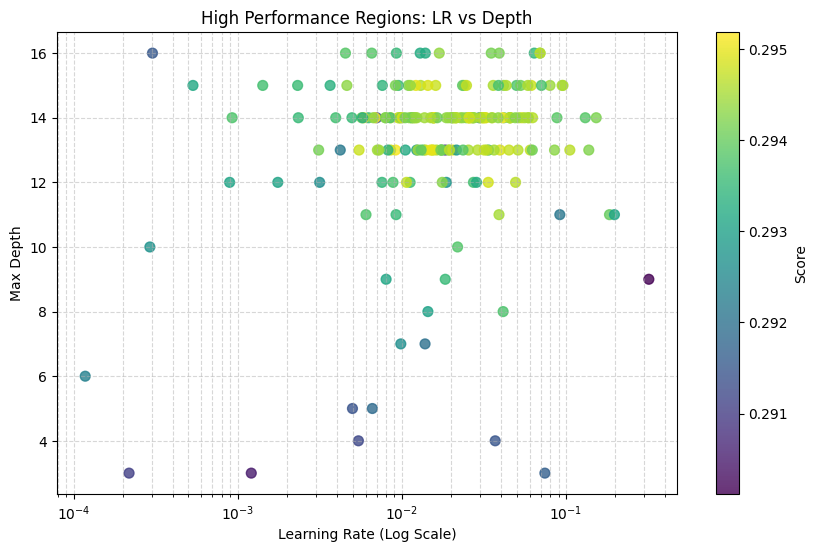

In [39]:
import optuna.visualization as vis

# 1. The "Contour Plot" - The best map for 2 parameters
# This will show you the exact "hotspots" for LR vs Depth
vis.plot_contour(optuna_study, params=['learning_rate', 'max_depth'])

# 2. The "Scatter Plot" - To see the high-performance clusters
# This plots every trial. Look for the dense clusters of blue dots.
fig = vis.plot_slice(optuna_study, params=['learning_rate', 'max_depth'])
fig.show()

# 3. Custom Matplotlib Plot (If you want static, printable plots like mine)
import matplotlib.pyplot as plt
import seaborn as sns

# Extract data
df = optuna_study.trials_dataframe()
df = df[df.state == 'COMPLETE'] # Filter only finished trials
df = df[df.value > 0.29]        # Zoom in on the top performers

plt.figure(figsize=(10, 6))
sc = plt.scatter(df['params_learning_rate'], df['params_max_depth'], 
                 c=df['value'], cmap='viridis', s=50, alpha=0.8)
plt.colorbar(sc, label='Score')
plt.xscale('log') # Crucial for Learning Rate!
plt.xlabel('Learning Rate (Log Scale)')
plt.ylabel('Max Depth')
plt.title('High Performance Regions: LR vs Depth')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

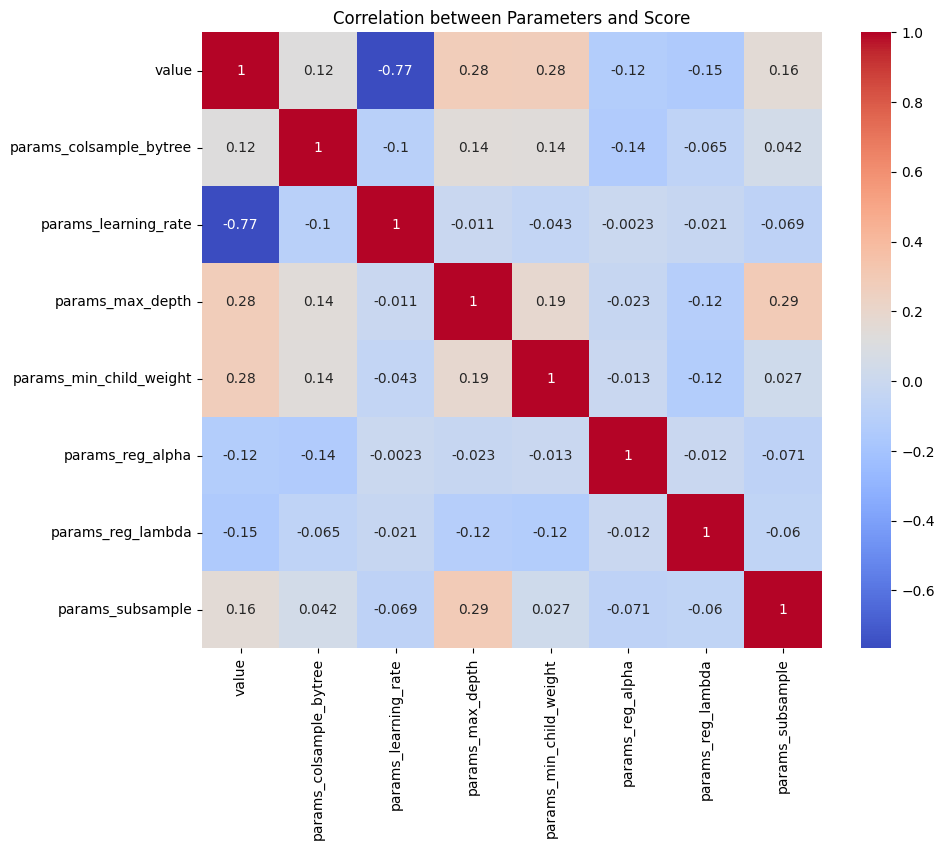

In [37]:
# Create a heatmap of parameter correlation
# This helps you see if parameters are fighting each other
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric parameter columns and the objective value
param_cols = [c for c in df.columns if 'params_' in c and df[c].dtype in [np.float64, np.int64]]
cols_to_plot = ['value'] + param_cols

plt.figure(figsize=(10,8))
sns.heatmap(df[cols_to_plot].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation between Parameters and Score")
plt.show()